# 01 Dqn Implementation

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement DQN with experience replay and target network
- Train on simple RL environments

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 3**.

---


## Lesson Brief

This lesson introduces **Deep Q-Networks (DQN)** as the extension of Q-learning to larger or continuous observation spaces.

Students will see why a neural network is used instead of a table, and why replay buffers and target networks are needed for stability.

Why this matters: DQN is often the first deep RL algorithm students encounter in practice.

It links tabular RL ideas to neural-network-based learning.

## Big Idea

DQN extends Q-learning by replacing the Q-table with a neural network.

This matters when the observation space is too large or continuous for a simple
lookup table.

## What to watch for

As you read the implementation, track four moving parts:

- Q-network
- target network
- replay buffer
- epsilon-greedy exploration

## Why DQN is different from tabular Q-learning

Tabular Q-learning stores one value per state-action pair.

DQN instead learns a function:

\[
Q_\theta(s,a)
\]

That makes it more scalable, but also less stable without extra tricks.

## Stability reminders

DQN is more delicate than Unit 2 methods.

Without replay buffers and target networks, training can become unstable because
both the data distribution and the learning target keep changing.

## Reading strategy

Do not try to memorize every line at once.

Instead, read the code in this order:

1. network definition
2. action selection
3. replay storage
4. Bellman target
5. optimizer step

## 🌍 Real-World Worked Example — CartPole with DQN

**Industry context:**
- Boston Dynamics uses policy gradient variants (similar to DQN) for robot balance control
- Tesla's Autopilot reward signal includes smooth lane-keeping (like CartPole balance)

We train a **DQN agent** to balance a pole on a cart using raw observations from OpenAI Gymnasium.

Episode   0 | Avg reward (last 30): 13.0 | ε=0.995


Episode  30 | Avg reward (last 30): 24.6 | ε=0.856


Episode  60 | Avg reward (last 30): 28.0 | ε=0.737


Episode  90 | Avg reward (last 30): 24.7 | ε=0.634


Episode 120 | Avg reward (last 30): 28.7 | ε=0.545


Episode 150 | Avg reward (last 30): 26.2 | ε=0.469


Episode 180 | Avg reward (last 30): 38.6 | ε=0.404


Episode 210 | Avg reward (last 30): 44.1 | ε=0.347


Episode 240 | Avg reward (last 30): 67.8 | ε=0.299


Episode 270 | Avg reward (last 30): 93.7 | ε=0.257


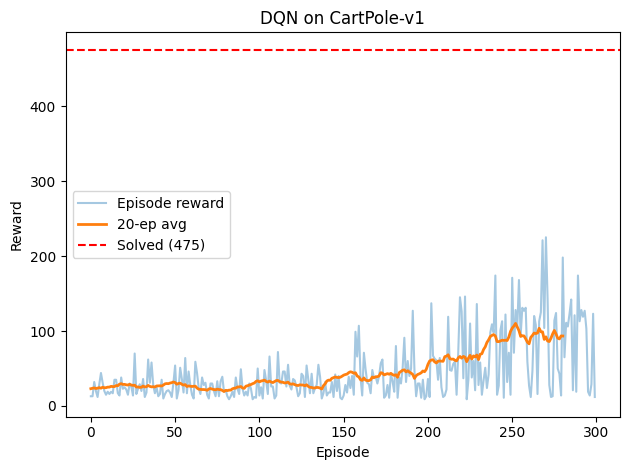

In [1]:
import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
import numpy as np, random, collections, matplotlib.pyplot as plt

torch.manual_seed(42); np.random.seed(42)

env = gym.make('CartPole-v1')

# ── DQN Network ──────────────────────────────────────────────────────────
class DQN(nn.Module):
    def __init__(self, obs=4, act=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs,128), nn.ReLU(),
            nn.Linear(128,128), nn.ReLU(),
            nn.Linear(128, act)
        )
    def forward(self, x): return self.net(x)

policy_net = DQN(); target_net = DQN()
target_net.load_state_dict(policy_net.state_dict())
opt     = optim.Adam(policy_net.parameters(), lr=1e-3)
memory  = collections.deque(maxlen=10000)
GAMMA   = 0.99; EPS = 1.0; EPS_MIN = 0.05; EPS_DECAY = 0.995
BATCH   = 64; rewards_ep = []

for episode in range(300):
    obs,_ = env.reset(); total_r = 0
    for t in range(500):
        if random.random() < EPS:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = policy_net(torch.tensor(obs).float().unsqueeze(0)).argmax().item()
        obs2, r, done, trunc, _ = env.step(action)
        memory.append((obs, action, r, obs2, done or trunc))
        obs = obs2; total_r += r
        # ── Train ────────────────────────────────────────────────────────
        if len(memory) >= BATCH:
            batch = random.sample(memory, BATCH)
            s,a,r_b,s2,d = zip(*batch)
            S=torch.tensor(np.array(s)).float(); A=torch.tensor(a).long()
            R=torch.tensor(r_b).float(); S2=torch.tensor(np.array(s2)).float()
            D=torch.tensor(d).float()
            Q_pred = policy_net(S).gather(1,A.unsqueeze(1)).squeeze()
            with torch.no_grad():
                Q_next = target_net(S2).max(1)[0]
            Q_target = R + GAMMA*Q_next*(1-D)
            loss = nn.MSELoss()(Q_pred, Q_target)
            opt.zero_grad(); loss.backward(); opt.step()
        if done or trunc: break
    EPS = max(EPS*EPS_DECAY, EPS_MIN)
    rewards_ep.append(total_r)
    if episode%50==0: target_net.load_state_dict(policy_net.state_dict())
    if episode%30==0: print(f"Episode {episode:3d} | Avg reward (last 30): {np.mean(rewards_ep[-30:]):.1f} | ε={EPS:.3f}")

env.close()
plt.plot(rewards_ep, alpha=0.4, label="Episode reward")
plt.plot(np.convolve(rewards_ep, np.ones(20)/20, 'valid'), label="20-ep avg", lw=2)
plt.title("DQN on CartPole-v1"); plt.xlabel("Episode"); plt.ylabel("Reward")
plt.axhline(475, color='red', linestyle='--', label="Solved (475)"); plt.legend()
plt.tight_layout(); plt.show()

## 📝 Summary

In this notebook, you learned:
- The **DQN algorithm**: approximating Q-values with a neural network instead of a table
- **Experience replay**: storing transitions in a replay buffer and sampling random mini-batches to break correlations
- **Target network**: a periodically-updated copy of the Q-network that stabilizes training
- How to set up an **OpenAI Gym** environment loop: observe → act → store → sample → update

**Next steps:** Study advanced DQN variants (Double DQN, Dueling DQN, Prioritized Experience Replay) and policy-gradient methods like PPO in later units.

## 📚 References & Further Reading

**Papers:**
- Watkins & Dayan (1992) — [Q-Learning](https://link.springer.com/article/10.1007/BF00992698)
- Mnih et al. (2015) — [DQN: Human-level control via deep RL](https://www.nature.com/articles/nature14236)
- Van Hasselt et al. (2016) — [Double DQN](https://arxiv.org/abs/1509.06461)

**OpenAI Gym:** [Gymnasium Documentation](https://gymnasium.farama.org/)

**State-of-the-Art:** DQN variants power game-playing AI and robotics controllers at Google DeepMind.

## Closing Takeaway

**Teaching takeaway:** DQN scales Q-learning by replacing the table with a neural network and stabilizing training with replay and target networks.

**If students remember one idea:** Deep RL is not just tabular RL with more code. Stability tricks are essential because the target and the function approximator both move during learning.

**Quick check before moving on:**
- Can you explain why replay buffers reduce harmful correlations in training data?
- Can you describe why a separate target network improves stability?

**Bridge to the next step:** Next, students will study actor-critic methods, which split the learning problem into policy and value roles.
